In [237]:
import os
import sys

In [ ]:
import os
import rpy2.robjects as robjects

from rpy2.robjects import pandas2ri, default_converter, conversion

import torch
import pyro
from rpy2.robjects import r, vectors
from rpy2 import rinterface


In [238]:
sys.path.insert(1, "/Users/jonathanhori/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/python")

# Load data

In [ ]:
conversion._converter = None
conversion.set_conversion(default_converter)
readRDS = robjects.r['readRDS']

# sim_data = readRDS('~/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/sim/simple_data/factor_data_n1000p500_snr2.2.rds')
sim_data = readRDS('~/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/sim/simple_data/factor_data_n2000p10000_snr2.2.rds')
        

In [687]:
print(sim_data)

$L
[1] 1

$N
[1] 1000

$p_l
$p_l[[1]]
[1] 500


$K
[1] 5

$K_l
[1] 5 5 5

$X_l
$X_l[[1]]
                [,1]         [,2]         [,3]          [,4]         [,5]
   [1,]  1.177905140  1.533916370 -1.176212489 -1.9037578529  -2.08438041
   [2,]  0.023210628  1.749655400 -3.140896352  1.3216771674  -4.29943692
   [3,] -1.467007382 -1.206368657  3.980691630 -0.2470350170  -1.88630140
   [4,]  1.994602850 -0.192307291 -2.412231954  0.5097938772   8.38560925
   [5,] -1.694557762 -2.375435890  2.865144362 -0.1038917946   0.70817434
   [6,]  3.304537411 -0.563677132  1.851326837 -0.7365756662   1.13213396
   [7,]  3.440415182  0.711360269  1.889353843 -1.0526778157  -0.94055188
   [8,] -0.846539603 -0.183869986 -0.086741550  0.7090651861   3.98892923
   [9,]  2.638909952  1.256284670  1.148508570 -0.4748716856   0.32935970
  [10,] -0.485976217 -1.509770669 -0.757771988 -0.8716477477  -2.75346047
  [11,] -1.014886361  0.620951115  1.931899365 -0.4150882110  -2.44147992
  [12,] -1.868894128 -2

Example of how to load data from imported RDS object

In [ ]:
conversion._converter = None
conversion.set_conversion(default_converter)

y = sim_data.rx2("y")
y = torch.tensor(y)

y.shape

input_dims = [tuple(robjects.r['dim'](x)) for x in sim_data.rx2("X_l")]

conversion.set_conversion(default_converter)
X_l_list = [torch.reshape(torch.tensor(X_l), dim[::-1]).t() for X_l, dim in zip(sim_data.rx2("X_l"), input_dims)]

In [60]:
X_l_list

[tensor([[ 3.5653,  2.5394,  1.7821,  ..., -2.2001, -3.4227, -0.7908],
         [-2.6507, -4.4605,  0.7055,  ...,  0.8528,  1.9446,  1.6031],
         [ 0.7118, -1.7884, -1.9219,  ..., -0.2510,  1.1944, -4.4862],
         ...,
         [-1.0198,  0.0519, -0.5344,  ...,  3.2747,  2.7392, -4.0464],
         [ 1.9547,  2.6448,  0.6074,  ...,  1.3020,  1.8865, -7.0354],
         [ 2.4521, -6.2190, -2.1554,  ..., -0.2033, -1.8714,  3.8354]]),
 tensor([[ 2.9954,  5.2949,  5.9221,  ...,  0.4287,  2.1419,  2.3828],
         [-3.2804,  3.0971, -0.7446,  ...,  0.2926,  4.3520,  3.4192],
         [ 1.0830,  3.8120, -4.1961,  ...,  0.9845,  5.2805,  3.0751],
         ...,
         [-5.8642,  2.7423, -1.0810,  ...,  5.1275,  4.0079,  1.1486],
         [ 0.9519,  3.5886, -2.0386,  ...,  3.1141,  6.4908,  4.4095],
         [-0.4200,  2.3703,  4.1633,  ...,  0.4601, -0.9553, -3.0760]]),
 tensor([[-5.9166e-01,  1.1712e+00, -2.5700e+00,  ...,  4.7326e+00,
          -1.9800e+00,  1.6019e+00],
         [ 

Process entire RDS file

In [624]:

def floatmatrix_to_torch(m):
    t = torch.tensor(list(m), dtype=torch.float32)
    # R matrices are stored column-major, so reshape and transpose
    t = t.view(m.ncol, m.nrow).t()
    return t

def r_to_torch(obj):
    """Recursively convert R objects (via rpy2) to Python/PyTorch equivalents."""
    
    # Case 1: R list (possibly named)
    if isinstance(obj, vectors.ListVector):
        names = getattr(obj, "names", None)
        if names is not None and not isinstance(names, rinterface.NULLType):
            return {name: r_to_torch(obj.rx2(name)) for name in names}
        else:
            return [r_to_torch(el) for el in obj]
    
    # Case 2: R matrix
    elif isinstance(obj, vectors.FloatMatrix):
        return floatmatrix_to_torch(obj)
    
    # Case 3: Numeric / integer / logical R vector
    elif isinstance(obj, (vectors.FloatSexpVector, vectors.IntSexpVector, vectors.BoolSexpVector)):
        return torch.tensor(list(obj), dtype=torch.float32)
    
    # Case 4: R data frame
    elif isinstance(obj, vectors.DataFrame):
        return {col: r_to_torch(obj.rx2(col)) for col in obj.names}
    
    # Case 5: Python list
    elif isinstance(obj, list):
        return [r_to_torch(el) for el in obj]
    
    # Case 6: R NULL
    elif isinstance(obj, rinterface.NULLType):
        return None
    
    # Fallback
    else:
        return obj

In [688]:
conversion.set_conversion(default_converter)
sim_data_torch = {name: r_to_torch(sim_data.rx2(name)) for name in sim_data.names}

sim_data_torch

{'L': tensor([1.]),
 'N': tensor([1000.]),
 'p_l': [tensor([500.])],
 'K': tensor([5.]),
 'K_l': tensor([5., 5., 5.]),
 'X_l': [tensor([[ 1.1779,  1.5339, -1.1762,  ..., -3.4987,  0.2064,  0.4991],
          [ 0.0232,  1.7497, -3.1409,  ..., -0.0280,  3.9680,  0.9326],
          [-1.4670, -1.2064,  3.9807,  ..., -0.2304,  1.4694,  1.5251],
          ...,
          [ 1.3440,  3.6002,  0.9047,  ...,  3.1943,  0.0200,  1.2820],
          [-2.7507, -2.1598, -0.8081,  ..., -0.0932,  1.9424,  0.0403],
          [ 0.9554, -2.1536, -3.2814,  ...,  0.6993,  2.2653, -1.3169]])],
 'Lambda_l': [tensor([[-0.5605, -0.6019, -0.9958, -0.8210, -0.5116],
          [-0.2302, -0.9937, -1.0400, -0.3073,  0.2369],
          [ 1.5587,  1.0268, -0.0180, -0.9021, -0.5416],
          ...,
          [ 0.1648, -1.3511,  1.0188,  0.2774, -0.2102],
          [ 0.3641, -0.5226,  1.0891,  0.5369,  1.4513],
          [ 0.5522, -0.2492, -0.1631, -0.4605,  0.6416]])],
 'Z': tensor([[-0.6788,  0.5743, -0.7045, -0.5340,  

In [639]:
conversion.set_conversion(default_converter)
[floatmatrix_to_torch(x[1]) for x in sim_data.items()]

[tensor([[ 1.1779,  1.5339, -1.1762,  ..., -3.4987,  0.2064,  0.4991],
         [ 0.0232,  1.7497, -3.1409,  ..., -0.0280,  3.9680,  0.9326],
         [-1.4670, -1.2064,  3.9807,  ..., -0.2304,  1.4694,  1.5251],
         ...,
         [ 1.3440,  3.6002,  0.9047,  ...,  3.1943,  0.0200,  1.2820],
         [-2.7507, -2.1598, -0.8081,  ..., -0.0932,  1.9424,  0.0403],
         [ 0.9554, -2.1536, -3.2814,  ...,  0.6993,  2.2653, -1.3169]])]

In [ ]:
conversion.set_conversion(default_converter)
[name for name in sim_data.names()]

TypeError: 'NULLType' object is not callable

In [ ]:
conversion.set_conversion(default_converter)
X = floatmatrix_to_torch(next(sim_data.items())[1])
# X = 

In [692]:
X = sim_data_torch["X_l"][0]

In [693]:
X.shape

torch.Size([1000, 500])

# Load data into model

In [256]:
import importlib


In [807]:
importlib.reload(sys.modules["matrix_decomp"])
from matrix_decomp import bayesian_factor_model, train_decomp, predict_factor_model

In [366]:
sim_data_torch["X_l"][0]

tensor([[ 3.5653,  2.5394,  1.7821,  ..., -2.2001, -3.4227, -0.7908],
        [-2.6507, -4.4605,  0.7055,  ...,  0.8528,  1.9446,  1.6031],
        [ 0.7118, -1.7884, -1.9219,  ..., -0.2510,  1.1944, -4.4862],
        ...,
        [-1.0198,  0.0519, -0.5344,  ...,  3.2747,  2.7392, -4.0464],
        [ 1.9547,  2.6448,  0.6074,  ...,  1.3020,  1.8865, -7.0354],
        [ 2.4521, -6.2190, -2.1554,  ..., -0.2033, -1.8714,  3.8354]])

In [572]:
X_l_tensor = torch.utils.data.TensorDataset(sim_data_torch["X_l"][0])
loader = torch.utils.data.DataLoader(X_l_tensor, batch_size = len(X_l_tensor))
one_batch, = next(iter(loader))
one_batch.shape

torch.Size([500, 100])

In [ ]:
# torch.is_tensor(X_l_tensor)
# X_l_tensor[0][0].shape[0]
# X_l_tensor

In [ ]:
# for x in X_l_tensor:
#     print(x)

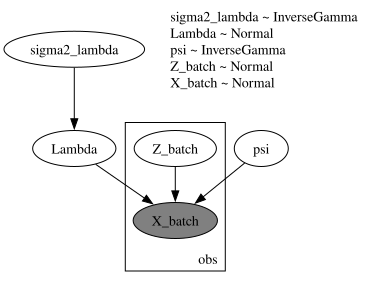

In [592]:
pyro.render_model(
    bayesian_factor_model, 
    model_args = (one_batch,
                  5,
                  one_batch[0].shape[0] #sim_data_torch["X_l"][0].shape[0] 
    ),
    render_distributions=True, 
    render_params=True,
    render_deterministic = True)

In [543]:
pyro.clear_param_store()


In [ ]:

X = one_batch
k = 5
n = X.shape[0]

In [528]:
pyro.get_param_store().get_all_param_names()

dict_keys([])

In [546]:
pyro.clear_param_store()

In [786]:
pyro.clear_param_store()
opt_minibatch = train_decomp(X, #sim_data_torch["X_l"][0], #X, 
                   k, 
                   epochs = 500,
                   minibatch_flag = True,
                   minibatch_size = 4,
                   opt_args = {"lr": 0.001,
                               "weight_decay": 0.5}) #,
                #    minibatch_size = sim_data_torch["X_l"][0].shape[0])

Epoch 1/500  avg neg-ELBO per datum: 540074.0475
Loss at epoch 1: 2430.017656458378
Epoch 2/500  avg neg-ELBO per datum: 483463.0542
Loss at epoch 2: 1964.0389861357212
Epoch 3/500  avg neg-ELBO per datum: 441889.2497
Loss at epoch 3: 1412.7381603747606
Epoch 4/500  avg neg-ELBO per datum: 410174.6041
Loss at epoch 4: 1445.2930695331097
Epoch 5/500  avg neg-ELBO per datum: 385952.1243
Loss at epoch 5: 1638.886927936554
Epoch 6/500  avg neg-ELBO per datum: 366919.5042
Loss at epoch 6: 1380.5838387827873
Epoch 7/500  avg neg-ELBO per datum: 351868.5632
Loss at epoch 7: 1487.9845674271583
Epoch 8/500  avg neg-ELBO per datum: 339749.7827
Loss at epoch 8: 1589.9448850383758
Epoch 9/500  avg neg-ELBO per datum: 329989.2235
Loss at epoch 9: 1175.1812256895303
Epoch 10/500  avg neg-ELBO per datum: 322285.1424
Loss at epoch 10: 1430.51727555418
Epoch 11/500  avg neg-ELBO per datum: 315846.8993
Loss at epoch 11: 1400.469136968136
Epoch 12/500  avg neg-ELBO per datum: 310709.5450
Loss at epoch 12

KeyboardInterrupt: 

Pass full dataset as Tensor into model training. Tolerance is at scale of difference in ELBO by iteration.

In [815]:
pyro.clear_param_store()
opt = train_decomp(X,
                   k, 
                   minibatch_flag = False,
                   tol = 1)

Iteration 0  loss: 2290.9030
Iteration 100  loss: 2144.4167
Iteration 200  loss: 1959.9137
Iteration 300  loss: 1752.9199
Iteration 400  loss: 1578.9816
Iteration 500  loss: 1439.3477
Iteration 600  loss: 1321.3043
Iteration 700  loss: 1239.6546
Iteration 800  loss: 1161.4347
Iteration 900  loss: 1104.3659
Iteration 1000  loss: 1060.7040
Iteration 1100  loss: 1027.7530
Iteration 1200  loss: 1004.1297
Iteration 1300  loss: 988.0458
Iteration 1400  loss: 971.5594
Iteration 1500  loss: 961.3838
Iteration 1600  loss: 951.3614
Iteration 1700  loss: 943.6929
Iteration 1800  loss: 937.2607
Iteration 1900  loss: 933.4650
Iteration 2000  loss: 927.8386
Iteration 2100  loss: 924.0129
Iteration 2200  loss: 921.8866
Iteration 2300  loss: 919.4020
Iteration 2400  loss: 917.3301
Iteration 2500  loss: 915.1258
Iteration 2600  loss: 913.4216
Iteration 2700  loss: 912.3705
Iteration 2800  loss: 910.6761
Iteration 2900  loss: 909.9336
Iteration 3000  loss: 908.6574
Iteration 3033  loss: 908.7001
Iterati

In [ ]:
# opt.params

AttributeError: 'SVI' object has no attribute 'params'

In [749]:
opt.evaluate_loss(X) / X.shape[0]

903.54983984375

In [695]:
pyro.get_param_store().get_all_param_names()

dict_keys(['AutoNormal.locs.sigma2_lambda', 'AutoNormal.scales.sigma2_lambda', 'AutoNormal.locs.Lambda', 'AutoNormal.scales.Lambda', 'AutoNormal.locs.psi', 'AutoNormal.scales.psi', 'AutoNormal.locs.Z_batch', 'AutoNormal.scales.Z_batch'])

In [ ]:
# torch.exp(pyro.param("AutoNormal.locs.sigma2_lambda"))

tensor([0.5794, 0.5824, 0.5962, 0.5980, 0.6013], grad_fn=<ExpBackward0>)

In [816]:
for name in pyro.get_param_store().get_all_param_names():
    print(name)
    print(pyro.param(name))

AutoNormal.locs.sigma2_lambda
Parameter containing:
tensor([-0.0610, -0.0420,  0.0444,  0.0063,  0.0325], requires_grad=True)
AutoNormal.scales.sigma2_lambda
tensor([0.0766, 0.0770, 0.0751, 0.0773, 0.0786], grad_fn=<SoftplusBackward0>)
AutoNormal.locs.Lambda
Parameter containing:
tensor([[ 0.8711, -1.1444, -0.6463, -0.5102,  0.1225],
        [ 0.5346, -0.5685, -1.1887,  0.0285,  0.5754],
        [ 1.2308,  0.1146,  1.4912,  0.6849,  0.3319],
        ...,
        [-1.3666, -0.2775,  0.1128, -0.1079,  1.0761],
        [-1.4534,  0.6585, -0.2674,  1.2684,  0.2901],
        [ 0.2918, -0.0116, -0.2419,  0.9023,  0.3781]], requires_grad=True)
AutoNormal.scales.Lambda
tensor([[0.0557, 0.0619, 0.0574, 0.0470, 0.0462],
        [0.0510, 0.0501, 0.0603, 0.0446, 0.0459],
        [0.0700, 0.0626, 0.0713, 0.0553, 0.0597],
        ...,
        [0.0665, 0.0496, 0.0501, 0.0542, 0.0584],
        [0.0755, 0.0514, 0.0568, 0.0709, 0.0573],
        [0.0359, 0.0349, 0.0353, 0.0433, 0.0388]], grad_fn=<Softplu

In [817]:
Lambda_est = pyro.param("AutoNormal.locs.Lambda")
Z_est = pyro.param("AutoNormal.locs.Z_batch")
Z_est

Parameter containing:
tensor([[ 0.5897, -0.1102, -0.7653,  0.3190, -0.9835],
        [-0.8878, -0.8821, -0.4604,  1.8088, -0.7577],
        [ 0.6122,  0.7777,  1.1963,  1.4890,  0.6671],
        ...,
        [ 0.2104, -0.8959, -0.3458,  1.0606,  2.2066],
        [-0.8369,  1.2995, -0.0275,  1.3363, -1.3048],
        [-0.7267, -1.3839,  0.4953, -0.8689, -0.1678]], requires_grad=True)

In [843]:
pyro.param("AutoNormal.scales.Z_batch").shape

torch.Size([1000, 5])

In [818]:
Struct_est = Z_est @ Lambda_est.T
Struct_est

tensor([[ 0.8512,  0.7308, -0.5359,  ..., -1.9544, -0.6057,  0.2744],
        [-0.4820,  0.1897, -0.8929,  ...,  0.3957,  2.9070,  1.2081],
        [-1.8079, -1.1105,  3.8677,  ..., -0.3603,  1.3847,  1.4760],
        ...,
        [ 1.1612,  2.3327,  1.0997,  ...,  2.1822,  1.1821,  1.9467],
        [-3.0401, -1.8662, -0.4400,  ..., -0.7683,  3.3959,  0.4597],
        [ 1.0535, -0.3118, -0.9653,  ...,  1.3462, -1.1385, -1.1633]],
       grad_fn=<MmBackward0>)

In [770]:
# sim_data_torch["X_l"][0]
X

tensor([[ 1.1779,  1.5339, -1.1762,  ..., -3.4987,  0.2064,  0.4991],
        [ 0.0232,  1.7497, -3.1409,  ..., -0.0280,  3.9680,  0.9326],
        [-1.4670, -1.2064,  3.9807,  ..., -0.2304,  1.4694,  1.5251],
        ...,
        [ 1.3440,  3.6002,  0.9047,  ...,  3.1943,  0.0200,  1.2820],
        [-2.7507, -2.1598, -0.8081,  ..., -0.0932,  1.9424,  0.0403],
        [ 0.9554, -2.1536, -3.2814,  ...,  0.6993,  2.2653, -1.3169]])

In [819]:
Struct_sim = sim_data_torch["Z"] @ sim_data_torch["Lambda_l"][0].T
Struct_sim

tensor([[ 0.7786,  0.6658, -0.3934,  ..., -1.9165, -0.4774,  0.3397],
        [-0.5598, -0.1776, -0.5612,  ...,  0.3230,  2.6174,  1.1559],
        [-1.7781, -1.2506,  3.9881,  ..., -0.3047,  1.3279,  1.4491],
        ...,
        [ 1.3502,  2.3562,  1.0484,  ...,  2.2715,  1.0926,  2.0107],
        [-3.1362, -1.8773, -0.5210,  ..., -0.5932,  3.5229,  0.4092],
        [ 1.0600, -0.3816, -1.0065,  ...,  1.5706, -1.2119, -1.1648]])

In [820]:
# sim_data_torch["Lambda_l"][0]

In [821]:
# torch.norm(sim_data_torch["X_l"][0] - Struct_est) ** 2 / torch.norm(sim_data_torch["X_l"][0]) ** 2

In [822]:
torch.norm(Struct_est)

tensor(1524.2280, grad_fn=<LinalgVectorNormBackward0>)

In [823]:
torch.norm(Struct_sim - Struct_est) ** 2 / torch.norm(Struct_sim) ** 2

tensor(0.0102, grad_fn=<DivBackward0>)

In [824]:
def g(X, k, n):
    pyro.infer.autoguide.AutoNormal(lambda d: bayesian_factor_model(d, 5, 5000))
    
post_pred = predict_factor_model(bayesian_factor_model,
                                 g,
                                 1000,
                                #  [X, 5, X.shape[0]])
                                 {"X": X,
                                  "k": 5,
                                  "n": X.shape[0]})

In [825]:
post_pred

{'sigma2_lambda': tensor([[[1.3967, 2.0378, 0.7414, 0.7929, 1.4797]],
 
         [[0.8022, 0.5934, 2.7510, 0.6363, 0.4985]],
 
         [[1.3482, 2.1154, 2.0568, 0.3980, 0.6071]],
 
         ...,
 
         [[0.9633, 0.7537, 0.5004, 1.2309, 0.7612]],
 
         [[2.4475, 0.6041, 1.0976, 1.5434, 0.9241]],
 
         [[1.9688, 0.2820, 0.5730, 2.1770, 0.7208]]]),
 'Lambda': tensor([[[[-0.0273,  1.9108,  1.1915, -1.6983, -1.2315],
           [-1.8021,  0.4207, -1.0575, -0.9500,  1.3301],
           [ 1.2423,  0.6691, -1.0836, -1.3744,  0.2678],
           ...,
           [ 0.7173, -2.0683, -0.6635, -1.2230, -2.5300],
           [ 1.0756, -0.1710, -0.6137, -1.3493,  0.5411],
           [-1.4361,  1.3203, -0.6990, -0.2361,  1.0548]]],
 
 
         [[[ 0.2379,  0.0382,  2.6608, -0.6820,  0.9303],
           [-2.1693,  0.7569, -1.0762, -0.6662,  0.3773],
           [-0.7997,  0.3863, -0.9291,  0.1894, -0.4124],
           ...,
           [-0.0742,  0.0801, -0.6823,  1.4737,  1.8358],
         

In [805]:
def test_fn(X, k, n):
      print(X, k, n)

test_fn(**{"X": X, "k": 5,"n": X.shape[0]})

tensor([[ 1.1779,  1.5339, -1.1762,  ..., -3.4987,  0.2064,  0.4991],
        [ 0.0232,  1.7497, -3.1409,  ..., -0.0280,  3.9680,  0.9326],
        [-1.4670, -1.2064,  3.9807,  ..., -0.2304,  1.4694,  1.5251],
        ...,
        [ 1.3440,  3.6002,  0.9047,  ...,  3.1943,  0.0200,  1.2820],
        [-2.7507, -2.1598, -0.8081,  ..., -0.0932,  1.9424,  0.0403],
        [ 0.9554, -2.1536, -3.2814,  ...,  0.6993,  2.2653, -1.3169]]) 5 1000


In [831]:
[(a, b) for (a, b) in post_pred.items()]

[('sigma2_lambda',
  tensor([[[1.3967, 2.0378, 0.7414, 0.7929, 1.4797]],
  
          [[0.8022, 0.5934, 2.7510, 0.6363, 0.4985]],
  
          [[1.3482, 2.1154, 2.0568, 0.3980, 0.6071]],
  
          ...,
  
          [[0.9633, 0.7537, 0.5004, 1.2309, 0.7612]],
  
          [[2.4475, 0.6041, 1.0976, 1.5434, 0.9241]],
  
          [[1.9688, 0.2820, 0.5730, 2.1770, 0.7208]]])),
 ('Lambda',
  tensor([[[[-0.0273,  1.9108,  1.1915, -1.6983, -1.2315],
            [-1.8021,  0.4207, -1.0575, -0.9500,  1.3301],
            [ 1.2423,  0.6691, -1.0836, -1.3744,  0.2678],
            ...,
            [ 0.7173, -2.0683, -0.6635, -1.2230, -2.5300],
            [ 1.0756, -0.1710, -0.6137, -1.3493,  0.5411],
            [-1.4361,  1.3203, -0.6990, -0.2361,  1.0548]]],
  
  
          [[[ 0.2379,  0.0382,  2.6608, -0.6820,  0.9303],
            [-2.1693,  0.7569, -1.0762, -0.6662,  0.3773],
            [-0.7997,  0.3863, -0.9291,  0.1894, -0.4124],
            ...,
            [-0.0742,  0.0801, -0.68

In [ ]:
torch.mean(post_pred["Lambda"], dim = 0)

TypeError: reshape() missing 1 required positional arguments: "shape"

In [ ]:


svi_samples = {k: v.reshape(1000).detach().cpu().numpy()
                for k, v in post_pred.items()a
                if k != "obs"}

RuntimeError: shape '[5000]' is invalid for input of size 2500000